# Deep Learning Approach to IMDB Sentiment Analysis

<div align='center'>
<img src='https://repository-images.githubusercontent.com/446393339/d4481b17-7960-4f3c-b040-8507df57f81b' width='400'>
</div>

## Introduction

Sentiment analysis is one of the most important tasks in Natural Language Processing (NLP), with wide applications in review analysis, recommendation systems, and customer feedback monitoring. In this notebook, I built a movie review sentiment classifier using the IMDB Dataset of 50K Movie Reviews.

The main objective of this project is to classify reviews as **positive** or **negative** by transforming raw text into meaningful numerical features and training a deep learning model for binary classification.

In this workflow, I:
- explored the class distribution of the dataset,
- encoded sentiment labels,
- cleaned and normalized review text using **NeatText**,
- applied **lemmatization** with a custom analyzer,
- converted text into numerical vectors using **CountVectorizer** with **unigrams and bigrams**,
- and trained a **deep neural network** for sentiment prediction.

This notebook demonstrates how text preprocessing, feature extraction, and deep learning can be combined to solve a real-world NLP classification problem effectively.

In [1]:
!pip install neattext

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.7/114.7 kB 4.6 MB/s eta 0:00:00


## Imported Libraries

In [2]:
import pandas as pd
import seaborn as sns
import neattext as nfx
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from sklearn.metrics import classification_report, confusion_matrix
from textblob import TextBlob
import numpy as np
import matplotlib.pyplot as plt

2026-04-27 12:52:58.434599: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777294378.620977      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777294378.675966      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777294379.117160      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777294379.117206      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777294379.117209      23 computation_placer.cc:177] computation placer alr

## Read Data

In [3]:
df=pd.read_csv('/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')

## EDA

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
df.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [7]:
df.shape

(50000, 2)

In [8]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

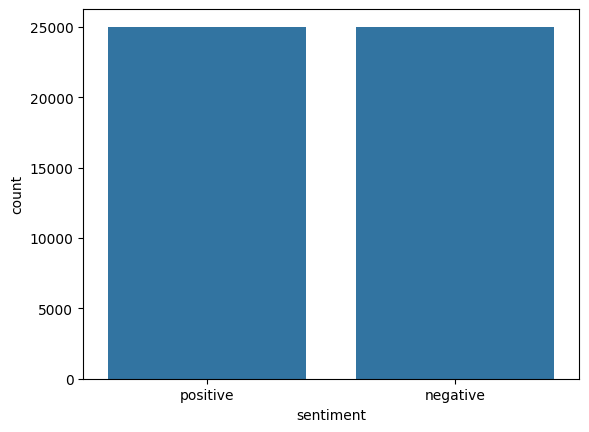

In [9]:
sns.countplot(x=df['sentiment']);

## LabelEncoder 

In [10]:
from sklearn.preprocessing import LabelEncoder 
le=LabelEncoder()
df['sentiment']=le.fit_transform(df['sentiment'])

In [11]:
df.sample(5)

,review,sentiment
176,This movie took me by surprise. The opening cr...,1
10410,"I was expecting ""Born to Kill"" to be an exciti...",0
28225,"I haven't seen a lot of episodes of ""Family Gu...",0
44638,Strange how less than 2 hours can seem like a ...,0
40297,This really is the worst movie I have ever see...,0


## Text Cleaning and Preprocessing with NeatText

In [12]:
# normalize
df['review']=df['review'].apply(nfx.normalize)

In [13]:
# clean_text
df['review']=df['review'].apply(nfx.clean_text)

In [14]:
# remove_special_characters
df['review']=df['review'].apply(nfx.remove_special_characters)

In [15]:
df['review'][0]

'reviewers mentioned watching oz episode hooked right exactly happened mebr br the thing struck oz brutality unflinching scenes violence set right word go trust me faint hearted timid pulls punches regards drugs sex violence hardcore classic use wordbr br it called oz nickname given oswald maximum security state penitentary focuses mainly emerald city experimental section prison cells glass fronts face inwards privacy high agenda em city home manyaryans muslims gangstas latinos christians italians irish moreso scuffles death stares dodgy dealings shady agreements far awaybr br i main appeal fact goes shows dare forget pretty pictures painted mainstream audiences forget charm forget romanceoz mess around episode saw struck nasty surreal ready it watched more developed taste oz got accustomed high levels graphic violence violence injustice crooked guards wholl sold nickel inmates wholl kill order away it mannered middle class inmates turned prison bitches lack street skills prison experi

## Join

In [16]:
s=''.join(df['review'])

In [17]:
s=nfx.clean_text(s)

In [18]:
s=nfx.remove_special_characters(s)

In [19]:
s=nfx.TextFrame(s)

In [20]:
s.describe()

Key      Value          
Length  : 37354787       
vowels  : 11709351       
consonants: 20429223       
stopwords: 0              
punctuations: 0              
special_char: 0              
tokens(whitespace): 5216214        
tokens(words): 5216214        


In [21]:
s.readability()

{'automated readability': 2608119.2996450583, 'description': None}

In [22]:
x=df['review']
y=df['sentiment']

In [23]:
def ekkok(review):
    words = TextBlob(review).words
    return [word.lemmatize() for word in words]

In [24]:
from sklearn.feature_extraction.text import CountVectorizer 
# Imports CountVectorizer, which transforms text documents into a matrix of token counts (numerical vectors

In [25]:
vect = CountVectorizer(stop_words='english', analyzer=ekkok, ngram_range=(1,2),max_features=10000)  
# Text vectorization configuration:
# - Uses lemmatization to normalize words to their base forms
# - Removes common English stopwords to reduce noise
# - Includes both unigrams and bigrams to capture contextual word relationships

x_vect = vect.fit_transform(x).toarray()  
# Transforms text documents into numerical feature vectors and stores the result as a NumPy array

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:533: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:539: UserWarning: The parameter 'stop_words' will not be used since 'analyzer' != 'word'
  warnings.warn(


In [26]:
x_train, x_test, y_train, y_test = train_test_split(x_vect, y, test_size=0.2, random_state=42)

In [27]:
model = Sequential([
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # classification 0 or 1
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])  

I0000 00:00:1777294497.869442      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [28]:
model.fit(x_train, y_train, batch_size=32, validation_data=(x_test, y_test), verbose=2, epochs=15)  

Epoch 1/15


I0000 00:00:1777294506.593907      73 service.cc:152] XLA service 0x7bfd84005310 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777294506.593967      73 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777294507.090423      73 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777294508.121735      73 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1250/1250 - 10s - 8ms/step - accuracy: 0.8649 - loss: 0.3233 - val_accuracy: 0.8863 - val_loss: 0.2740
Epoch 2/15
1250/1250 - 4s - 3ms/step - accuracy: 0.9406 - loss: 0.1510 - val_accuracy: 0.8814 - val_loss: 0.3127
Epoch 3/15
1250/1250 - 4s - 3ms/step - accuracy: 0.9901 - loss: 0.0301 - val_accuracy: 0.8741 - val_loss: 0.5180
Epoch 4/15
1250/1250 - 4s - 3ms/step - accuracy: 0.9982 - loss: 0.0062 - val_accuracy: 0.8741 - val_loss: 0.8167
Epoch 5/15
1250/1250 - 4s - 3ms/step - accuracy: 0.9982 - loss: 0.0055 - val_accuracy: 0.8761 - val_loss: 0.8377
Epoch 6/15
1250/1250 - 4s - 3ms/step - accuracy: 0.9988 - loss: 0.0040 - val_accuracy: 0.8734 - val_loss: 1.1558
Epoch 7/15
1250/1250 - 4s - 3ms/step - accuracy: 0.9981 - loss: 0.0059 - val_accuracy: 0.8752 - val_loss: 0.9060
Epoch 8/15
1250/1250 - 4s - 3ms/step - accuracy: 0.9982 - loss: 0.0055 - val_accuracy: 0.8773 - val_loss: 1.0747
Epoch 9/15
1250/1250 - 4s - 3ms/step - accuracy: 0.9994 - loss: 0.0022 - val_accuracy: 0.8779 - val_loss: 

In [29]:
model.evaluate(x_test, y_test) 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8747 - loss: 1.0438


[1.0816847085952759, 0.8762999773025513]

In [30]:
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test Loss:", loss)
print("Test Accuracy:", acc)

Test Loss: 1.0816847085952759
Test Accuracy: 0.8762999773025513


In [31]:
y_prob = model.predict(x_test)
y_pred = (y_prob > 0.5).astype(int).flatten()

print("First 10 predictions:", y_pred[:10])
print("First 10 actuals:    ", y_test.iloc[:10].values)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
First 10 predictions: [0 1 0 1 0 1 1 0 0 0]
First 10 actuals:     [1 1 0 1 0 1 1 1 0 0]


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.87      0.88      0.88      4961
           1       0.88      0.87      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



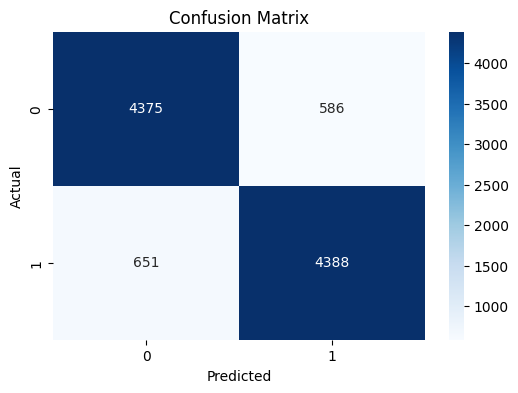

In [32]:
y_prob = model.predict(x_test)
y_pred = (y_prob > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Test

In [33]:
new_review = "This movie was absolutely amazing. The acting was great and I loved the story."

new_review = nfx.normalize(new_review)
new_review = nfx.clean_text(new_review)
new_review = nfx.remove_special_characters(new_review)

# vectorizer 
new_review_vect = vect.transform([new_review]).toarray()

# prediction
pred_prob = model.predict(new_review_vect)[0][0]
pred_class = 1 if pred_prob > 0.5 else 0

print("Prediction probability:", pred_prob)
print("Predicted class:", pred_class)
print("Predicted label:", le.inverse_transform([pred_class])[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
Prediction probability: 0.9999951
Predicted class: 1
Predicted label: positive


In [34]:
new_review = "This was a terrible movie. I hated the acting and the plot was boring."

new_review = nfx.normalize(new_review)
new_review = nfx.clean_text(new_review)
new_review = nfx.remove_special_characters(new_review)

new_review_vect = vect.transform([new_review]).toarray()

pred_prob = model.predict(new_review_vect)[0][0]
pred_class = 1 if pred_prob > 0.5 else 0

print("Prediction probability:", pred_prob)
print("Predicted label:", le.inverse_transform([pred_class])[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Prediction probability: 7.064641e-09
Predicted label: negative


In [35]:
sample_text = df['review'].iloc[4]

sample_vect = vect.transform([sample_text]).toarray()

pred_prob = model.predict(sample_vect)[0][0]
pred_class = 1 if pred_prob > 0.5 else 0

print("Review:", sample_text)
print("Predicted:", le.inverse_transform([pred_class])[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Review: petter matteis love time money visually stunning film watch mr mattei offers vivid portrait human relations movie telling money power success people different situations encounter br br this variation arthur schnitzlers play theme director transfers action present time new york different characters meet connect connected way person know previous point contact stylishly film sophisticated luxurious look taken people live world live habitatbr br the thing gets souls picture different stages loneliness inhabits big city exactly best place human relations find sincere fulfillment discerns case people encounterbr br the acting good mr matteis direction steve buscemi rosario dawson carol kane michael imperioli adrian grenier rest talented cast characters come alivebr br we wish mr mattei good luck await anxiously work
Predicted: positive


In [36]:
print("Actual:", le.inverse_transform([df['sentiment'].iloc[4]])[0])

Actual: positive


## Model Save

In [37]:
model.save("imdb_sentiment_model.keras")

##  Conclusion

In this project, I developed a sentiment analysis pipeline on the IMDB movie review dataset using NLP preprocessing, CountVectorizer-based feature extraction, and a deep learning classifier.

The model achieved a **test accuracy of 87.35%**, with balanced precision and recall scores across both sentiment classes. This shows that the model was able to learn meaningful patterns from the review text and perform reliable binary classification.

Some key takeaways from this project:
- Text cleaning and normalization helped reduce noise in the reviews.
- Lemmatization improved the consistency of word representations.
- Using **unigrams + bigrams** allowed the model to capture not only individual words but also short contextual phrases.
- The neural network learned the training data very strongly, while the validation performance suggests that the model may benefit from better regularization or architecture tuning.